In [2]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import constants as k
import utils
import pickle
# from torch.nn import TransformerEncoder
# from models.transformer_encoder import Encoder


In [3]:
data_dir = '/Users/rebekahzhang/data/neural_data'
pickle_dir = Path(os.path.join(data_dir, 'session_pickles'))

In [4]:
units_vetted = pd.read_csv(os.path.join(data_dir, 'units_vetted.csv'), index_col=0).sort_values('unit_id')
sessions_vetted = pd.read_csv(os.path.join(data_dir, 'sessions_vetted.csv'), index_col=0).sort_values('num_units')

In [5]:
session_id = 'RZ050_2024-11-20_str'
units_by_session = units_vetted.groupby("session_id")
test_session = units_by_session.get_group(session_id)
events, trials, units = utils.get_session_data(session_id, pickle_dir)

rough code

In [40]:
# Parameters
period = k.BACKGROUND
anchor = k.TO_CUE_OFF
time_step = 0.01  # seconds
t_start = -0.5
t_end = 0.0
n_bins = int((t_end - t_start) / time_step)
time_bins = np.linspace(t_start, t_end, n_bins + 1)  # Bin edges

In [41]:
def get_session_tws(trials):
    session_tws = trials['wait_length'].tolist()
    return session_tws

In [42]:
def get_essemble_fr(units, session_tws, anchor, period, time_bins):
    # Precompute firing rates for all units
    session_units_firing_rates = []
    num_trials = len(session_tws)
    for unit in units:
        # Filter spikes in BACKGROUND period and time window [-0.5, 0]
        spikes_in_background = unit.loc[unit.period == period]
        spikes_in_background_end = spikes_in_background[
            (spikes_in_background['to_cue_off'] >= -0.5) & 
            (spikes_in_background['to_cue_off'] <= 0)
        ]
        spikes_by_trial = spikes_in_background_end.groupby('trial_id')
        
        # Initialize firing rates for this unit (shape: num_trials x n_bins)
        unit_fr = np.zeros((num_trials, n_bins))
        
        for t in range(num_trials):
            try:
                trial_spikes = spikes_by_trial.get_group(t)
                spike_times = trial_spikes[anchor].values
                spike_counts, _ = np.histogram(spike_times, bins=time_bins)
                unit_fr[t] = spike_counts / time_step  # Firing rate (spikes/sec)
            except KeyError:
                pass  # Keep zeros if trial has no spikes
        
        session_units_firing_rates.append(unit_fr)

    # Assemble ensemble_fr: list of trials, each with shape (n_units, n_bins)
    ensemble_fr = [
        np.vstack([unit_fr[t] for unit_fr in session_units_firing_rates])  # Stack all units for trial t
        for t in range(num_trials)
    ]
    return ensemble_fr

In [ ]:
# session_id = 'RZ050_2024-11-20_str'
# units_by_session = units_vetted.groupby("session_id")
# test_session = units_by_session.get_group(session_id)
# events, trials, units = utils.get_session_data(session_id, pickle_dir)

# session_tws = get_session_tws(trials)
# ensemble_fr = get_essemble_fr(units, session_tws, anchor, time_bins)

# unit_0 = ensemble_fr[0]
# unit_1 = ensemble_fr[1]
# unit_2 = ensemble_fr[2]

In [24]:
ensemble_fr_all = []
tws = []

units_by_session = units_vetted.groupby("session_id")
for _, session_info in sessions_vetted.iterrows():
    session_id = session_info['id']
    _, trials, units = utils.get_session_data(session_id, pickle_dir)

    session_tws = get_session_tws(trials)
    ensemble_fr = get_essemble_fr(units, session_tws, anchor, time_bins)

    ensemble_fr_all.extend(ensemble_fr)
    tws.extend(session_tws)

In [25]:
len(ensemble_fr_all), len(tws)

(33462, 33462)

In [34]:
with open(os.path.join(data_dir,'ensemble_fr_to_tw.pickle'), 'wb') as handle:
    pickle.dump((ensemble_fr_all, tws), handle, protocol=pickle.HIGHEST_PROTOCOL)

loading data

In [35]:
with open(os.path.join(data_dir,'ensemble_fr_to_tw.pickle'), 'rb') as handle:
    ensemble_fr, tws = pickle.load(handle)

In [36]:
shapes = [fr.shape[0] for fr in ensemble_fr]

(array([4233., 3849., 1611., 3403., 1498., 1021., 1585., 1647.,  704.,
         514., 1407., 1701.,  754.,  933., 1437.,  821., 1229.,  316.,
         697.,  477.,    0.,  487.,  453.,    0.,  444.,    0.,  529.,
           0.,  363.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,  365.,    0.,    0.,    0.,    0.,  687.,    0.,
           0.,    0.,    0.,    0.,  297.]),
 array([  1.  ,   5.14,   9.28,  13.42,  17.56,  21.7 ,  25.84,  29.98,
         34.12,  38.26,  42.4 ,  46.54,  50.68,  54.82,  58.96,  63.1 ,
         67.24,  71.38,  75.52,  79.66,  83.8 ,  87.94,  92.08,  96.22,
        100.36, 104.5 , 108.64, 112.78, 116.92, 121.06, 125.2 , 129.34,
        133.48, 137.62, 141.76, 145.9 , 150.04, 154.18, 158.32, 162.46,
        166.6 , 170.74, 174.88, 179.02, 183.16, 187.3 , 191.44, 195.58,
        199.72, 203.86, 208.  ]),
 <BarContainer object of 50 artists>)

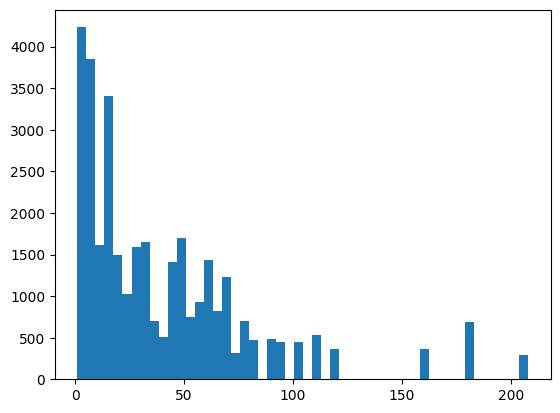

In [37]:
plt.hist(shapes, bins=50)

In [39]:
len(shapes)

33462